# Kenny Courser Spring 2023

In [2]:
from sklearn.datasets import fetch_openml
# mnist = fetch_openml('mnist_784')
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

C:\Users\Kenny\miniconda3\envs\tf\lib\site-packages\sklearn\datasets\_openml.py:932: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


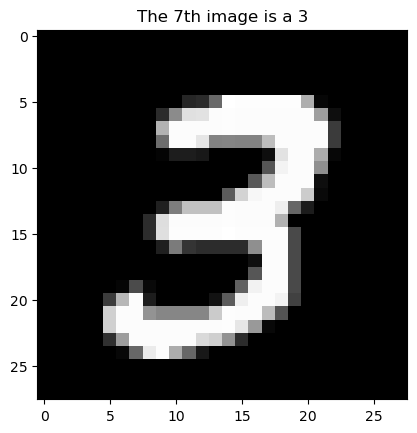

In [3]:
import matplotlib.pyplot as plt
plt.title('The 7th image is a {label}'.format(label=int(y[7])))
plt.imshow(X[7].reshape((28,28)), cmap='gray')
plt.show()

In [4]:
import numpy as np

# Split the data into subsets based on class labels
X4 = X[y == '4', :]
X9 = X[y == '9', :]

# Shuffle each subset
np.random.shuffle(X4)
np.random.shuffle(X9)

# Create the training set
X_train = np.concatenate((X4[:3000, :], X9[:3000, :]), axis=0)

y_train = np.concatenate((np.full(3000, 4), np.full(3000, 9)))

# Create the holdout set
X_holdout = np.concatenate((X4[3000:4000, :], X9[3000:4000, :]), axis=0)

y_holdout = np.concatenate((np.full(1000, 4), np.full(1000, 9)))

# Create the test set
X_test = np.concatenate((X4[4000:, :], X9[4000:, :]), axis=0)

num_4_test = X4.shape[0] - 4000
num_9_test = X9.shape[0] - 4000

y_test = np.concatenate((4*np.ones(num_4_test), 9*np.ones(num_9_test)), axis=0)

In [193]:
np.shape(X_holdout)

(2000, 784)

In [194]:
np.shape(y_holdout)

(2000,)

In [191]:
np.shape(X_train)

(6000, 784)

In [192]:
np.shape(y_train)

(6000,)

In [195]:
np.shape(X_test)

(5782, 784)

In [196]:
np.shape(y_test)

(5782,)

In [5]:
C_range = np.logspace(-8, 2, 22)

In [6]:
from sklearn import svm

In [199]:
clf= svm.SVC(C=1.0,kernel='linear')
y = y.astype(float)

In [203]:
for c in C_range:
    clf = svm.SVC(C=c, kernel='linear')
    clf.fit(X_train, y_train)
    Pe = 1 - clf.score(X_holdout, y_holdout)
    print(f"C = {c:.15f}, Pe = {Pe:.15f}")

C = 0.000000010000000, Pe = 0.047500000000000
C = 0.000000029935773, Pe = 0.041500000000000
C = 0.000000089615050, Pe = 0.036500000000000
C = 0.000000268269580, Pe = 0.033000000000000
C = 0.000000803085722, Pe = 0.030000000000000
C = 0.000002404099184, Pe = 0.031000000000000
C = 0.000007196856730, Pe = 0.029000000000000
C = 0.000021544346900, Pe = 0.035500000000000
C = 0.000064494667710, Pe = 0.038500000000000
C = 0.000193069772888, Pe = 0.039000000000000
C = 0.000577969288415, Pe = 0.051000000000000
C = 0.001730195738846, Pe = 0.050500000000000
C = 0.005179474679231, Pe = 0.054000000000000
C = 0.015505157798326, Pe = 0.054000000000000
C = 0.046415888336128, Pe = 0.054000000000000
C = 0.138949549437314, Pe = 0.054000000000000
C = 0.415956216307184, Pe = 0.054000000000000
C = 1.245197084735032, Pe = 0.054000000000000
C = 3.727593720314938, Pe = 0.054000000000000
C = 11.158839925077480, Pe = 0.054000000000000
C = 33.404849835132445, Pe = 0.054000000000000
C = 100.000000000000000, Pe = 0.

# The lowest probability of error occurs when $C=0.000007196856730$.

In [9]:
# Combine the training sets and holdout sets

X_train_and_holdout = np.concatenate((X_train, X_holdout), axis=0)
y_train_and_holdout = np.concatenate((y_train, y_holdout), axis=0)

In [209]:
clf = svm.SVC(C=0.000007196856730, kernel='linear')
clf.fit(X_train_and_holdout, y_train_and_holdout)
Pe = 1 - clf.score(X_test,y_test)
Pe

0.033379453476305776

# $3.34$% probability of error

# 2.4a)

In [7]:
C_range2 = np.logspace(-4, 6, 22)

In [238]:
for c in C_range2:
    clf = svm.SVC(C=c, kernel='poly',degree=1)
    clf.fit(X_train, y_train)
    Pe = 1 - clf.score(X_holdout, y_holdout)
    print(f"C = {c:.15f}, Pe = {Pe:.15f}")

C = 0.000100000000000, Pe = 0.182000000000000
C = 0.000299357729472, Pe = 0.182000000000000
C = 0.000896150501947, Pe = 0.182000000000000
C = 0.002682695795280, Pe = 0.140000000000000
C = 0.008030857221392, Pe = 0.072000000000000
C = 0.024040991835100, Pe = 0.052500000000000
C = 0.071968567300115, Pe = 0.044000000000000
C = 0.215443469003188, Pe = 0.040500000000000
C = 0.644946677103762, Pe = 0.034000000000000
C = 1.930697728883250, Pe = 0.030500000000000
C = 5.779692884153313, Pe = 0.031000000000000
C = 17.301957388458945, Pe = 0.029500000000000
C = 51.794746792312019, Pe = 0.031000000000000
C = 155.051577983262206, Pe = 0.038500000000000
C = 464.158883361277276, Pe = 0.039000000000000
C = 1389.495494373136125, Pe = 0.043500000000000
C = 4159.562163071843315, Pe = 0.051000000000000
C = 12451.970847350319673, Pe = 0.054000000000000
C = 37275.937203149376728, Pe = 0.054000000000000
C = 111588.399250774804386, Pe = 0.054000000000000
C = 334048.498351324407849, Pe = 0.054000000000000
C = 

# Optimal value of $C$ is $17.301957388458945$ with a $2.95$% probability of error.

In [10]:
clf1 = svm.SVC(C=17.301957388458945, kernel='poly', degree=1)
clf1.fit(X_train_and_holdout, y_train_and_holdout)
Pe = 1 - clf1.score(X_test, y_test)
Pe

0.03286060186786577

# ~$3.286$% probability of error.

In [12]:
clf1.support_vectors_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [13]:
np.shape(clf1.support_vectors_)

(727, 784)

# $727$ support vectors

In [239]:
for c in C_range2:
    clf = svm.SVC(C=c, kernel='poly', degree=2)
    clf.fit(X_train, y_train)
    Pe = 1 - clf.score(X_holdout, y_holdout)
    print(f"C = {c:.15f}, Pe = {Pe:.15f}")

C = 0.000100000000000, Pe = 0.109000000000000
C = 0.000299357729472, Pe = 0.109000000000000
C = 0.000896150501947, Pe = 0.109000000000000
C = 0.002682695795280, Pe = 0.087000000000000
C = 0.008030857221392, Pe = 0.054500000000000
C = 0.024040991835100, Pe = 0.037000000000000
C = 0.071968567300115, Pe = 0.026000000000000
C = 0.215443469003188, Pe = 0.020000000000000
C = 0.644946677103762, Pe = 0.018500000000000
C = 1.930697728883250, Pe = 0.015000000000000
C = 5.779692884153313, Pe = 0.014500000000000
C = 17.301957388458945, Pe = 0.013500000000000
C = 51.794746792312019, Pe = 0.014500000000000
C = 155.051577983262206, Pe = 0.014500000000000
C = 464.158883361277276, Pe = 0.014500000000000
C = 1389.495494373136125, Pe = 0.014500000000000
C = 4159.562163071843315, Pe = 0.014500000000000
C = 12451.970847350319673, Pe = 0.014500000000000
C = 37275.937203149376728, Pe = 0.014500000000000
C = 111588.399250774804386, Pe = 0.014500000000000
C = 334048.498351324407849, Pe = 0.014500000000000
C = 

# Same optimal value of $C$ with a $1.35$% probability of error.

In [26]:
clf2 = svm.SVC(C=17.301957388458945, kernel='poly', degree=2)
clf2.fit(X_train_and_holdout, y_train_and_holdout)
Pe = 1 - clf2.score(X_test, y_test)
Pe

0.009858180560359697

# ~$0.9858$% probability of error

In [27]:
clf2.support_vectors_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [28]:
np.shape(clf2.support_vectors_)

(703, 784)

# $703$ support vectors

# 2.4b)

In [249]:
C_range3 = np.logspace(-5, 5, 10)
gamma_range = np.logspace(-5, 5, 10)

In [250]:
for c in C_range3:
    for gamma in gamma_range:
        clf = svm.SVC(C=c, kernel='rbf', gamma=gamma)
        clf.fit(X_train, y_train)
        Pe = 1 - clf.score(X_holdout, y_holdout)
        print(f"C = {c:.15f},Gamma={gamma:.15f}, Pe = {Pe:.15f}")

C = 0.000010000000000,Gamma=0.000010000000000, Pe = 0.496000000000000
C = 0.000010000000000,Gamma=0.000129154966501, Pe = 0.020500000000000
C = 0.000010000000000,Gamma=0.001668100537200, Pe = 0.499500000000000
C = 0.000010000000000,Gamma=0.021544346900319, Pe = 0.500000000000000
C = 0.000010000000000,Gamma=0.278255940220713, Pe = 0.500000000000000
C = 0.000010000000000,Gamma=3.593813663804626, Pe = 0.500000000000000
C = 0.000010000000000,Gamma=46.415888336127821, Pe = 0.500000000000000
C = 0.000010000000000,Gamma=599.484250318942145, Pe = 0.500000000000000
C = 0.000010000000000,Gamma=7742.636826811277388, Pe = 0.500000000000000
C = 0.000010000000000,Gamma=100000.000000000000000, Pe = 0.500000000000000
C = 0.000129154966501,Gamma=0.000010000000000, Pe = 0.496000000000000
C = 0.000129154966501,Gamma=0.000129154966501, Pe = 0.020500000000000
C = 0.000129154966501,Gamma=0.001668100537200, Pe = 0.499500000000000
C = 0.000129154966501,Gamma=0.021544346900319, Pe = 0.500000000000000
C = 0.000

# The optimalvalue of gamma looks to be low, so we'll do a more refined search with low values.

In [252]:
C_range4 = np.logspace(-5, 5, 10)
gamma_range2 = np.logspace(-6, -4, 3)

for c in C_range4:
    for gamma in gamma_range2:
        clf = svm.SVC(C=c, kernel='rbf', gamma=gamma)
        clf.fit(X_train, y_train)
        Pe = 1 - clf.score(X_holdout, y_holdout)
        print(f"C = {c:.15f},Gamma={gamma:.15f}, Pe = {Pe:.15f}")

C = 0.000010000000000,Gamma=0.000001000000000, Pe = 0.225500000000000
C = 0.000010000000000,Gamma=0.000010000000000, Pe = 0.496000000000000
C = 0.000010000000000,Gamma=0.000100000000000, Pe = 0.020500000000000
C = 0.000129154966501,Gamma=0.000001000000000, Pe = 0.225500000000000
C = 0.000129154966501,Gamma=0.000010000000000, Pe = 0.496000000000000
C = 0.000129154966501,Gamma=0.000100000000000, Pe = 0.020500000000000
C = 0.001668100537200,Gamma=0.000001000000000, Pe = 0.225500000000000
C = 0.001668100537200,Gamma=0.000010000000000, Pe = 0.496000000000000
C = 0.001668100537200,Gamma=0.000100000000000, Pe = 0.499500000000000
C = 0.021544346900319,Gamma=0.000001000000000, Pe = 0.169500000000000
C = 0.021544346900319,Gamma=0.000010000000000, Pe = 0.496000000000000
C = 0.021544346900319,Gamma=0.000100000000000, Pe = 0.499500000000000
C = 0.278255940220713,Gamma=0.000001000000000, Pe = 0.024000000000000
C = 0.278255940220713,Gamma=0.000010000000000, Pe = 0.496000000000000
C = 0.27825594022071

# Gamma=$.000001$ looks to be optimal of these. There might be a more optimal value of gamma, but these iterations take quite a long time to run. With a faster processor, I would try to find a better value.

In [253]:
for c in C_range2:
    clf = svm.SVC(C=c, kernel='rbf', gamma=.000001)
    clf.fit(X_train, y_train)
    Pe = 1 - clf.score(X_holdout, y_holdout)
    print(f"C = {c:.15f},Gamma={gamma:.15f}, Pe = {Pe:.15f}")

C = 0.000100000000000,Gamma=0.000100000000000, Pe = 0.225500000000000
C = 0.000299357729472,Gamma=0.000100000000000, Pe = 0.225500000000000
C = 0.000896150501947,Gamma=0.000100000000000, Pe = 0.225500000000000
C = 0.002682695795280,Gamma=0.000100000000000, Pe = 0.225500000000000
C = 0.008030857221392,Gamma=0.000100000000000, Pe = 0.225500000000000
C = 0.024040991835100,Gamma=0.000100000000000, Pe = 0.160500000000000
C = 0.071968567300115,Gamma=0.000100000000000, Pe = 0.066000000000000
C = 0.215443469003188,Gamma=0.000100000000000, Pe = 0.027000000000000
C = 0.644946677103762,Gamma=0.000100000000000, Pe = 0.008500000000000
C = 1.930697728883250,Gamma=0.000100000000000, Pe = 0.008000000000000
C = 5.779692884153313,Gamma=0.000100000000000, Pe = 0.008500000000000
C = 17.301957388458945,Gamma=0.000100000000000, Pe = 0.008500000000000
C = 51.794746792312019,Gamma=0.000100000000000, Pe = 0.008500000000000
C = 155.051577983262206,Gamma=0.000100000000000, Pe = 0.008500000000000
C = 464.15888336

# Optimal value of $C$ is $1.930697728883250$.

In [35]:
clf3 = svm.SVC(C=1.930697728883250, kernel='rbf', gamma=.000001)
clf3.fit(X_train_and_holdout, y_train_and_holdout)
Pe = 1 - clf3.score(X_test, y_test)
Pe

0.010377032168799705

# ~$1.0377$% probability of error

In [36]:
clf3.support_vectors_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [37]:
np.shape(clf3.support_vectors_)

(3410, 784)

# $3410$ support vectors

# 2.4c)

# Linear kernel

In [55]:
distances = clf1.decision_function(clf1.support_vectors_)
sorted_distances = np.argsort(np.abs(distances))
support_vector_indices = clf1.support_[sorted_distances[:16]]

In [24]:
support_vector_indices

array([5035, 7103, 4483, 5322, 2005, 2130, 4695, 3562,  877, 3897, 1382,
       3461, 6187, 6712, 5138, 7472])

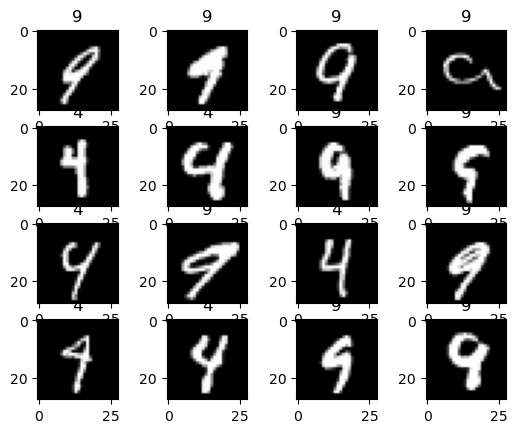

In [56]:
f, axarr = plt.subplots(4, 4)
for i in range(4):
    for j in range(4):
        idx = i*4 + j
        axarr[i,j].imshow(X_train_and_holdout[support_vector_indices[idx]].reshape((28,28)), cmap='gray')
        axarr[i,j].set_title('{label}'.format(label=int(y_train_and_holdout[support_vector_indices[idx]])))
plt.show()

# The closer the support vectors lie to the decision boundary, the larger the violation of the margin (or in other words, the closer to the decision boundary a support vector is, the further away it is from the corresponding supporting hyperplane). We sort the distances in ascending order and then identify the support vectors that violate the margin by the largest amount.

# Quadratic kernel

In [51]:
distances2 = clf2.decision_function(clf2.support_vectors_)
sorted_distances2 = np.argsort(np.abs(distances2))
support_vector_indices2 = clf2.support_[sorted_distances2[:16]]

In [33]:
support_vector_indices2

array([7500,  431, 5411, 5944,  395, 6323, 1595, 1581, 7307, 4475, 4677,
       1644,  816,  352, 3598, 1710])

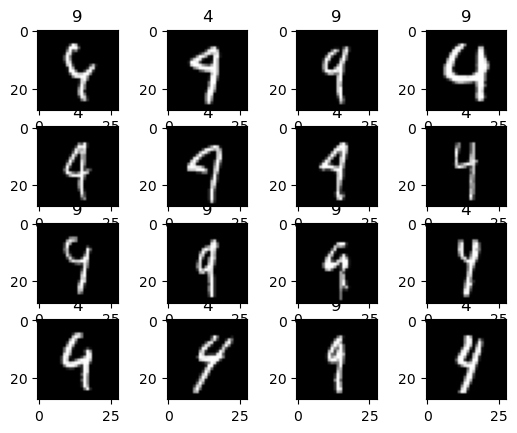

In [52]:
f, axarr = plt.subplots(4, 4)
for i in range(4):
    for j in range(4):
        idx = i*4 + j
        axarr[i,j].imshow(X_train_and_holdout[support_vector_indices2[idx]].reshape((28,28)), cmap='gray')
        axarr[i,j].set_title('{label}'.format(label=int(y_train_and_holdout[support_vector_indices2[idx]])))
plt.show()

# RBF kernel

In [46]:
distances3 = clf3.decision_function(clf3.support_vectors_)
sorted_distances3 = np.argsort(np.abs(distances3))
support_vector_indices3 = clf3.support_[sorted_distances3[:16]]

In [47]:
support_vector_indices3

array([ 431, 5944, 7500,  395, 5247, 1595, 6187, 5328, 7307,  994,  401,
       1915, 1551, 1371, 2030, 1393])

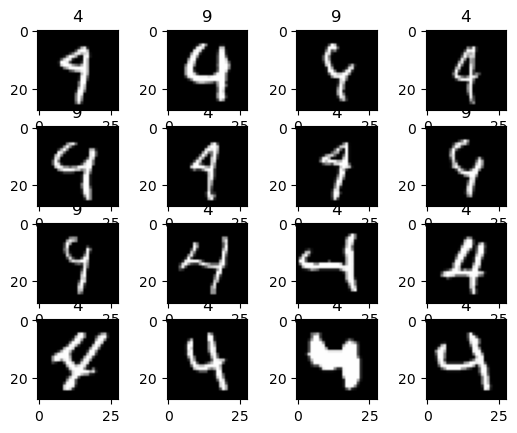

In [48]:
f, axarr = plt.subplots(4, 4)
for i in range(4):
    for j in range(4):
        idx = i*4 + j
        axarr[i,j].imshow(X_train_and_holdout[support_vector_indices3[idx]].reshape((28,28)), cmap='gray')
        axarr[i,j].set_title('{label}'.format(label=int(y_train_and_holdout[support_vector_indices3[idx]])))
plt.show()